In [9]:
import numpy as np
from numpy.linalg import eigh
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# ============================================================
# Parameters
# ============================================================
sigma = 0.5
N = 20  # number of seeds (0 to 19)

# ============================================================
# Load denoised images (N, H, W, C) and ground truth (H, W, C)
# ============================================================
image_name = "terminator"
data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data", image_name)

images = []
for seed in range(N):
    path = f"{data_dir}/recon/sigma{sigma}/{seed}_00000.png"
    img = np.array(Image.open(path)).astype(np.float64) / 255.0
    images.append(img[...,:3])
images = np.stack(images)  # (N, H, W, C)
x_star = np.array(Image.open(f"{data_dir}/label/00000.png")).astype(np.float64) / 255.0
H, W, C = images.shape[1], images.shape[2], images.shape[3]


# ============================================================
# Step 1: Estimate the empirical covariance matrix of superpixels
# ============================================================
# Option A (default): per-image superpixel means → (N, D) → sample covariance
# Option B: randomly sample one pixel per superpixel across all images,
#           repeat n_realizations times → (n_realizations, D) → sample covariance.
#           This can produce more than N-1 nonzero eigenvalues.
# True: random pixel sampling, False: per-image superpixel means

USE_RANDOM_PIXEL_SAMPLING = True   # <-- toggle here
n_realizations = 1000               # number of random realizations (only used if True)

sp_mask = np.array(Image.open(f"{data_dir}/superpixels/labels_1000.png"))

sp_ids = np.unique(sp_mask)
n_sp = len(sp_ids)
D = n_sp * C  # total dimension: superpixels × channels

if USE_RANDOM_PIXEL_SAMPLING:
    # For each superpixel, collect all pixel locations
    sp_pixel_indices = {}  # sid -> array of (row, col) pairs
    for sid in sp_ids:
        rows, cols = np.where(sp_mask == sid)
        sp_pixel_indices[sid] = (rows, cols)

    # Build (n_realizations, D) matrix by random sampling
    rng = np.random.default_rng(seed=0)
    sp_means = np.zeros((n_realizations, D))
    for k, sid in enumerate(sp_ids):
        rows, cols = sp_pixel_indices[sid]
        n_pixels = len(rows)
        for r in range(n_realizations):
            # Pick a random image and a random pixel within this superpixel
            img_idx = rng.integers(0, N)
            pix_idx = rng.integers(0, n_pixels)
            for c in range(C):
                sp_means[r, c * n_sp + k] = images[img_idx, rows[pix_idx], cols[pix_idx], c]
else:
    # Build (N, D) matrix using per-image superpixel means
    sp_means = np.zeros((N, D))
    for k, sid in enumerate(sp_ids):
        pixel_mask = (sp_mask == sid)  # (H, W)
        for n in range(N):
            for c in range(C):
                sp_means[n, c * n_sp + k] = images[n, :, :, c][pixel_mask].mean()

cov_matrix = np.cov(sp_means, rowvar=False)  # (D, D)


# ============================================================
# Step 2: Eigendecomposition + truncation to top K components
# ============================================================
# eigh returns eigenvalues in ascending order; we reverse to descending.
# Then truncate to the K components that explain meaningful variance.

gamma_asc, U_asc = eigh(cov_matrix)
gamma_full = gamma_asc[::-1].copy()
U_full = U_asc[:, ::-1].copy()

# Truncate: keep components whose eigenvalue > threshold
# Rank of sample covariance is at most (number of observations - 1).
n_obs = n_realizations if USE_RANDOM_PIXEL_SAMPLING else N
threshold = 1e-10 * gamma_full[0]  # relative to largest eigenvalue
K = np.sum(gamma_full > threshold)
K = min(K, n_obs - 1)  # cannot exceed rank of sample covariance

gamma = gamma_full[:K]   # (K,)
U = U_full[:, :K]        # (D, K)

# Verify: U.T @ U = I_K (orthonormal columns)
assert np.allclose(U.T @ U, np.eye(K), atol=1e-8)



# ============================================================
# Step 3: Solve for lambda_k from gamma_k (K values only)
# ============================================================
# lambda_k = ((1 - 2*alpha*gamma_k) + sqrt(1 + 4*alpha*gamma_k)) / (2*gamma_k)

alpha = sigma ** (-2)
lam = ((1 - 2 * alpha * gamma) + np.sqrt(1 + 4 * alpha * gamma)) / (2 * gamma)  # (K,)



# ============================================================
# Step 4: Construct Lambda = U @ diag(lambda) @ U.T
# ============================================================
# U is (D, K), lam is (K,), so Lambda is (D, D) but rank K.

Lambda = U @ np.diag(lam) @ U.T  # (D, D)



# ============================================================
# Step 5: Empirical mean of each superpixel (mu_denoised)
# ============================================================
# Mean over ALL pixels in each superpixel across ALL images, per channel.

mu_denoised = np.zeros(D)
for k, sid in enumerate(sp_ids):
    pixel_mask = (sp_mask == sid)
    for c in range(C):
        mu_denoised[c * n_sp + k] = images[:, :, :, c][:, pixel_mask].mean()



# ============================================================
# Step 6: Compute mu = (I - B_alpha)^{-1} @ (mu_denoised - B_alpha @ x_star_sp)
# ============================================================
# With truncated basis (D x K):
#   B_alpha       = U @ diag(alpha / (lam + alpha)) @ U.T
#   (I - B_alpha) = I - U @ diag(alpha/(lam+alpha)) @ U.T
#                 = I + U @ diag(-alpha/(lam+alpha)) @ U.T
#
# Using Woodbury-like identity for the inverse:
#   (I - B_alpha)^{-1} = I + U @ diag(alpha / lam) @ U.T
#
# Proof: (I - B_alpha) acts as identity on the nullspace of U,
# and as diag(lam/(lam+alpha)) on the column space of U.
# Its inverse is identity on nullspace, diag((lam+alpha)/lam) on column space.
# = I + U @ diag((lam+alpha)/lam - 1) @ U.T = I + U @ diag(alpha/lam) @ U.T

# Map x_star to superpixel space (mean per superpixel, per channel)
x_star_sp = np.zeros(D)
for k, sid in enumerate(sp_ids):
    pixel_mask = (sp_mask == sid)
    for c in range(C):
        x_star_sp[c * n_sp + k] = x_star[:, :, c][pixel_mask].mean()

# B_alpha @ v = U @ diag(alpha/(lam+alpha)) @ U.T @ v
b_diag = alpha / (lam + alpha)  # (K,)

def apply_B_alpha(v):
    return U @ (b_diag * (U.T @ v))

# (I - B_alpha)^{-1} @ v = v + U @ diag(alpha/lam) @ U.T @ v
inv_diag = alpha / lam  # (K,)

def apply_inv_I_minus_B(v):
    return v + U @ (inv_diag * (U.T @ v))

# mu
residual = mu_denoised - apply_B_alpha(x_star_sp)
mu = apply_inv_I_minus_B(residual)

### Compute all metric combinations

Options:
- **pixel_mode**: `per_channel` (1D conditional per channel) or `per_pixel` (3D RGB conditional)
- **metric**: `unnormalized_deviation`, `normalized_deviation`, `typicality_signed`, `typicality_unsigned`
- **agg_mode**: `mean` (superpixel mean of x\*) or `sequence` (per-pixel evaluation, then average)
- **reduction** (per_channel only): `mean`, `max`, `norm` across R,G,B channels

In [10]:
# ============================================================
# Compute all metric combinations in one pass
# ============================================================
from itertools import product as iter_product

# --- Precompute shared quantities ---

# Superpixel-mean deviation and Lambda product (for "mean" aggregation)
diff_mean = x_star_sp - mu                            # (D,)
Lambda_diff_mean = U @ (lam * (U.T @ diff_mean))      # (D,) = Lambda @ diff_mean
diag_Lambda = np.sum(lam[None, :] * U ** 2, axis=1)   # (D,)
safe_mask_D = diag_Lambda > 1e-15

# Per-superpixel: pixel locations, RGB index triplet, 3x3 Lambda block
sp_pixel_locs = {}
for k, sid in enumerate(sp_ids):
    rows, cols = np.where(sp_mask == sid)
    sp_pixel_locs[k] = (rows, cols)

sp_idx = np.array([[c * n_sp + k for c in range(C)] for k in range(n_sp)])  # (n_sp, 3)

sp_Lambda_blocks = []   # (n_sp,) list of (3, 3)
for k in range(n_sp):
    U_k = U[sp_idx[k], :]                      # (3, K)
    sp_Lambda_blocks.append(U_k @ (lam[:, None] * U_k.T))

# --- Helper: apply metric formula to raw values ---

def _apply_metric_1d(diff_vals, Ld_vals, diag_L_vals, metric_name):
    """Per-channel metric.  All inputs broadcastable, same shape.
    Returns array of same shape."""
    if metric_name == "unnormalized_deviation":
        return diff_vals ** 2
    safe = diag_L_vals > 1e-15
    m = np.zeros_like(diff_vals)
    m[safe] = Ld_vals[safe] ** 2 / (2 * diag_L_vals[safe])
    if metric_name == "normalized_deviation":
        return m
    elif metric_name == "typicality_signed":
        return m - 0.5
    else:  # typicality_unsigned
        return np.abs(m - 0.5)


def _apply_metric_3d(delta, Lambda_k, metric_name):
    """Per-pixel (3D) metric.
    delta: (P, 3)  Lambda_k: (3, 3)
    Returns (P,)."""
    if metric_name == "unnormalized_deviation":
        return np.sum(delta ** 2, axis=1)
    Ld = delta @ Lambda_k.T                       # (P, 3)
    m = 0.5 * np.sum(delta * Ld, axis=1)          # (P,)  = 0.5 * delta^T Lambda delta
    if metric_name == "normalized_deviation":
        return m
    elif metric_name == "typicality_signed":
        return m - 1.5   # E[chi^2_3] / 2 = 3/2
    else:  # typicality_unsigned
        return np.abs(m - 1.5)


def _reduce_channels(vals, reduction):
    """vals: (n_sp, C) -> (n_sp,)"""
    if reduction == "mean":
        return vals.mean(axis=1)
    elif reduction == "max":
        return vals.max(axis=1)
    else:  # norm
        return np.linalg.norm(vals, axis=1)


def _to_image(m_sp):
    """Map (n_sp,) superpixel values to (H, W) image."""
    img = np.zeros((H, W))
    for k, sid in enumerate(sp_ids):
        img[sp_mask == sid] = m_sp[k]
    return img


# --- Main loop over all combinations ---

pixel_modes  = ["per_channel", "per_pixel"]
metric_names = ["unnormalized_deviation", "normalized_deviation",
                "typicality_signed", "typicality_unsigned"]
agg_modes    = ["mean", "sequence"]
reductions   = ["mean", "max", "norm"]

results = {}   # (pixel_mode, metric, agg, reduction_or_None) -> (H, W)

for pixel_mode, metric_name, agg_mode in iter_product(pixel_modes, metric_names, agg_modes):

    if pixel_mode == "per_channel":
        # ---- per-channel: 1D conditional per entry of D-vector ----

        if agg_mode == "mean":
            # Use precomputed superpixel-mean quantities
            m_D = _apply_metric_1d(diff_mean, Lambda_diff_mean,
                                   diag_Lambda, metric_name)        # (D,)
            m_per_sp = m_D.reshape(C, n_sp).T                       # (n_sp, C)
        else:
            # sequence: evaluate at each pixel, average over pixels
            m_per_sp = np.zeros((n_sp, C))
            for k in range(n_sp):
                idx_k = sp_idx[k]                                    # (3,)
                rows, cols = sp_pixel_locs[k]
                pixels = x_star[rows, cols, :C]                      # (P, 3)

                diff_k = pixels - mu[idx_k]                          # (P, 3)

                # Lambda_diff at idx_k per pixel (efficient delta update)
                delta_from_mean = pixels - x_star_sp[idx_k]          # (P, 3)
                Ld_k = (Lambda_diff_mean[idx_k][None, :]
                        + delta_from_mean @ sp_Lambda_blocks[k].T)   # (P, 3)
                diag_L_k = diag_Lambda[idx_k]                        # (3,)

                pixel_m = _apply_metric_1d(diff_k, Ld_k,
                                           np.broadcast_to(diag_L_k, Ld_k.shape),
                                           metric_name)              # (P, 3)
                m_per_sp[k] = pixel_m.mean(axis=0)

        # Reduce across channels
        for reduction in reductions:
            key = (pixel_mode, metric_name, agg_mode, reduction)
            results[key] = _to_image(_reduce_channels(m_per_sp, reduction))

    else:
        # ---- per-pixel: 3D (RGB) conditional per superpixel ----

        m_sp = np.zeros(n_sp)

        if agg_mode == "mean":
            for k in range(n_sp):
                delta_k = diff_mean[sp_idx[k]][None, :]              # (1, 3)
                m_sp[k] = _apply_metric_3d(delta_k,
                                           sp_Lambda_blocks[k],
                                           metric_name).item()
        else:
            # sequence: evaluate at each pixel, average
            for k in range(n_sp):
                rows, cols = sp_pixel_locs[k]
                pixels = x_star[rows, cols, :C]                      # (P, 3)
                delta_k = pixels - mu[sp_idx[k]]                     # (P, 3)
                m_sp[k] = _apply_metric_3d(delta_k,
                                           sp_Lambda_blocks[k],
                                           metric_name).mean()

        key = (pixel_mode, metric_name, agg_mode, None)
        results[key] = _to_image(m_sp)

In [11]:
for key in results.keys():
    print(key)

('per_channel', 'unnormalized_deviation', 'mean', 'mean')
('per_channel', 'unnormalized_deviation', 'mean', 'max')
('per_channel', 'unnormalized_deviation', 'mean', 'norm')
('per_channel', 'unnormalized_deviation', 'sequence', 'mean')
('per_channel', 'unnormalized_deviation', 'sequence', 'max')
('per_channel', 'unnormalized_deviation', 'sequence', 'norm')
('per_channel', 'normalized_deviation', 'mean', 'mean')
('per_channel', 'normalized_deviation', 'mean', 'max')
('per_channel', 'normalized_deviation', 'mean', 'norm')
('per_channel', 'normalized_deviation', 'sequence', 'mean')
('per_channel', 'normalized_deviation', 'sequence', 'max')
('per_channel', 'normalized_deviation', 'sequence', 'norm')
('per_channel', 'typicality_signed', 'mean', 'mean')
('per_channel', 'typicality_signed', 'mean', 'max')
('per_channel', 'typicality_signed', 'mean', 'norm')
('per_channel', 'typicality_signed', 'sequence', 'mean')
('per_channel', 'typicality_signed', 'sequence', 'max')
('per_channel', 'typicali

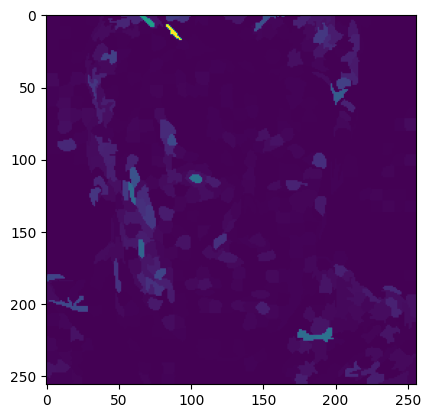

In [12]:
plt.imshow(results[('per_channel', 'unnormalized_deviation', 'mean', 'mean')])